In [1]:
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.rcParams["font.size"] = 14

from sk_utils import Utils as u
from sk_models import RetinalGanglionCellMosaic as RGCmodel

In [2]:
u.check_gpus()

GPUs present?	True	1
Device 0: NVIDIA RTX 6000 Ada Generation


30.000011135861595


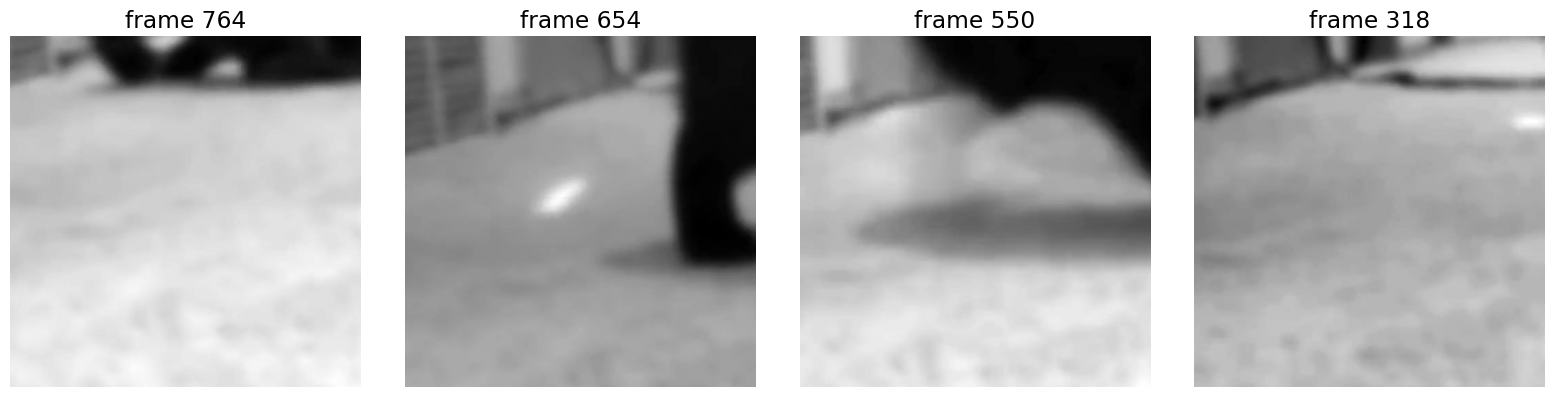

In [3]:
video, fps = u.read_video("lnp_naturalmovies/Video_2.mp4")
print(fps)

# let's crop (256, 256) patches
video_patch = np.array([f[500:1012, 500:1012] for f in video])

# just visualize a few frames
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
frames = np.random.uniform(0, len(video_patch), 4).astype(np.uint32)

for i,f in enumerate(frames):
    ax[i].imshow(video_patch[f], cmap="gray")
    ax[i].axis("off")
    ax[i].set_title(f"frame {f}")

fig.set_tight_layout(True)
plt.show()

In [4]:
model_parameters = {
    "cell_type": "ON_Parasol",
    "max_firing_rate": 700,
    "spatial": {
        "width": 35,
        "height": 35,
        "center_size": 300/(30 * 2),
        "surround_size": 2*300/30,
        "center_strength": 1,
        "surround_strength": -0.5
    },
    "temporal": {
        "memory_ms": 250,
        "amp1": 0.6,
        "amp2": 0.3,
        "peak1_ms": 35,
        "peak2_ms": 55,
        "width1_ms": 21,
        "width2_ms": 38
    },
    "tiling_config": {
        "n_cells": None, 
        "rf_diameter": 35,
        "base_spacing": 6.0, 
        "offset": [0, 0],
        "coverage_factor": 1.0,
        "selection_method": "center_first"
    },
    "nonlinearity": {
        "alpha": 1,
        "beta": 2,
        "gamma": 0,
        "type": "soft-rectifier"
    }
}

video_parameters = {
    "frame_shape": (512, 512),
    "frame_rate": fps
}

In [5]:
test_model = RGCmodel(model_parameters=model_parameters, video_parameters=video_parameters)

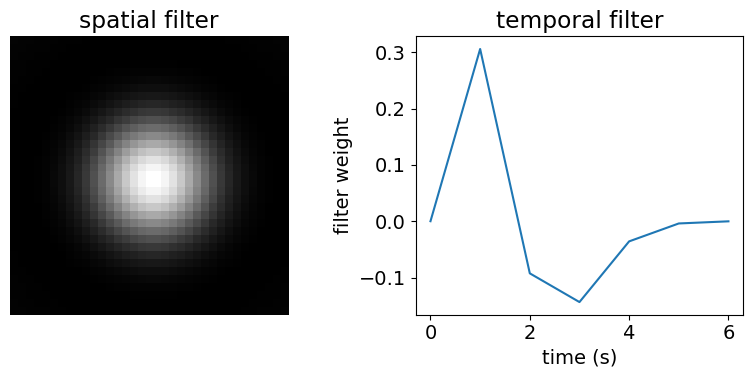

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(test_model.spatial_filter, cmap="gray")
ax[0].set_title("spatial filter")
ax[0].axis("off")

ax[1].plot(test_model.temporal_filter)
ax[1].set_title("temporal filter")
ax[1].set_xlabel("time (s)")
ax[1].set_ylabel("filter weight")

fig.set_tight_layout(True)
plt.show()

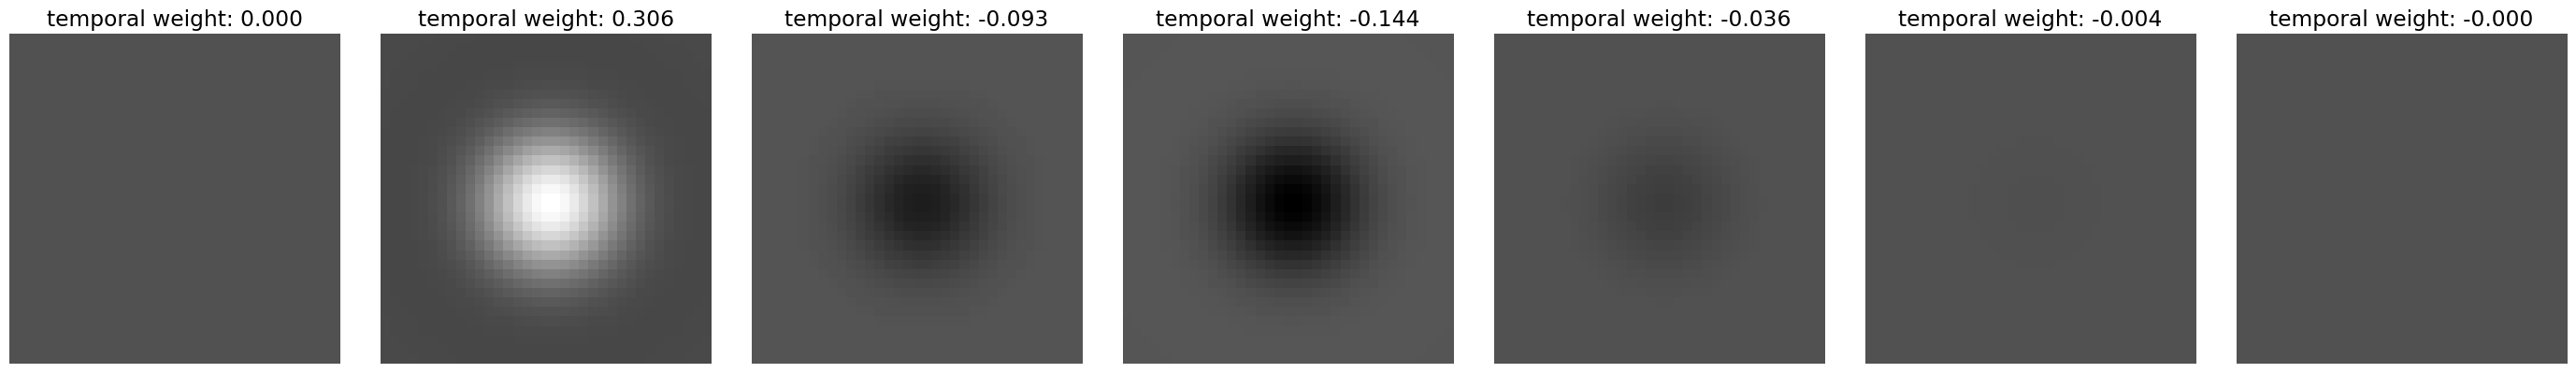

In [7]:
fig, ax = plt.subplots(1, len(test_model.temporal_filter), figsize=(len(test_model.temporal_filter)*4, 4))
min_v = test_model.spatiotemporal_filter.min()
max_v = test_model.spatiotemporal_filter.max()

for i,a in enumerate(ax):
    a.imshow(
        test_model.spatiotemporal_filter[i], cmap="gray", 
        vmin=min_v, vmax=max_v
        )
    a.axis("off")

    # set attr
    a.set_title(f"temporal weight: {test_model.temporal_filter[i]:.3f}")

fig.set_tight_layout(True)
plt.show()

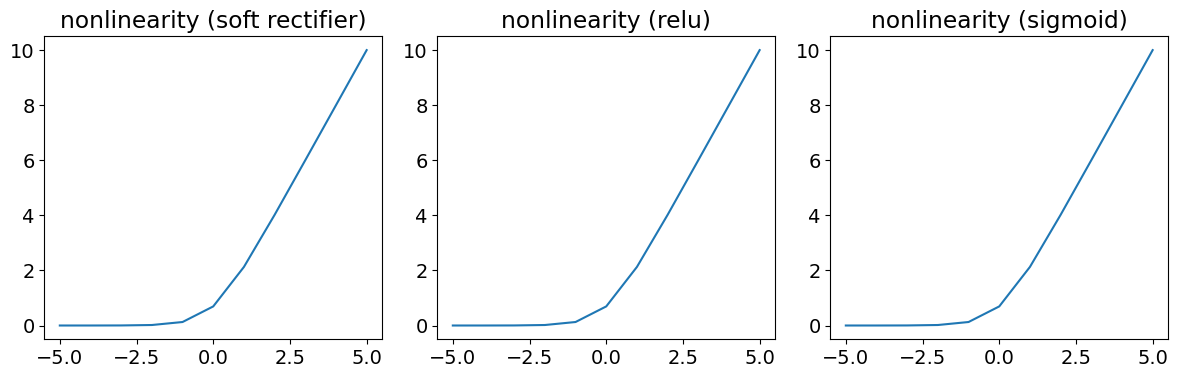

In [8]:
# the nonlinearity
x = np.arange(-5, 6)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].plot(x, test_model.nonlinearity(torch.Tensor(x)))
ax[0].set_title("nonlinearity (soft rectifier)")

ax[1].plot(x, test_model.nonlinearity(torch.Tensor(x)))
ax[1].set_title("nonlinearity (relu)")

ax[2].plot(x, test_model.nonlinearity(torch.Tensor(x)))
ax[2].set_title("nonlinearity (sigmoid)")

fig.set_tight_layout(True)
plt.show()

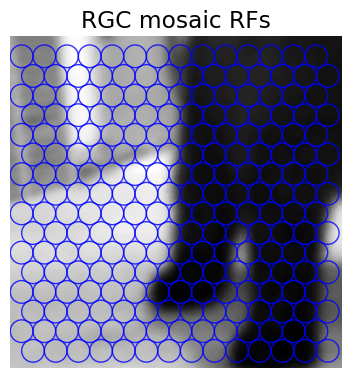

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.imshow(video_patch[627], cmap="gray")

# Plot receptive fields
for x, y in test_model.mosaic:
    circle = patches.Circle((x, y), test_model.m_params["tiling_config"]["rf_diameter"]/2, 
                                    linewidth=1, edgecolor='blue', 
                                    facecolor='none', alpha=0.8)
    ax.add_patch(circle)
    
ax.set_title("RGC mosaic RFs")

ax.axis("off")
fig.set_tight_layout(True)
plt.show()

In [10]:
# okay, video is working, let's see if we can create some spikes
generator, firing_rate = test_model.forward(video_patch)
times, counts = test_model.spikes(firing_rate)

generator.shape, firing_rate.shape, len(times)

(torch.Size([224, 892]), torch.Size([224, 892]), 224)

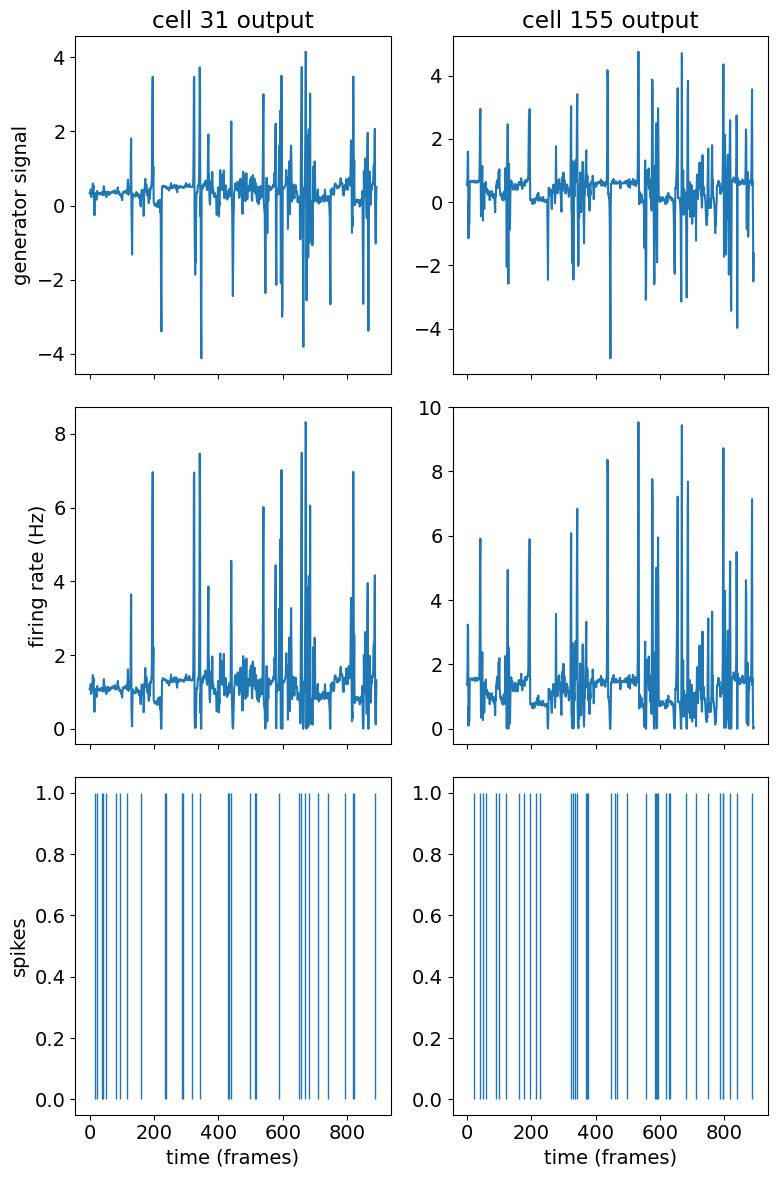

In [11]:
rand_cell = np.random.randint(0, generator.shape[0], 2)

# plot for 2 random cells
fig, ax = plt.subplots(3, 2, figsize=(8, 12), sharex=True)
for i,r in enumerate(rand_cell):

    # plot the generator signal, firing rate, and spikes for a random cell
    ax[0][i].plot(generator[r])
    ax[1][i].plot(firing_rate[r])
    ax[2][i].vlines(np.arange(len(generator[r]))[counts[r] == 1], 0, 1, linewidth=1)

    # set axis labels
    if i == 0:
        ax[0][i].set_ylabel("generator signal")
        ax[1][i].set_ylabel("firing rate (Hz)")
        ax[2][i].set_ylabel("spikes")
    ax[2][i].set_xlabel("time (frames)")

    # set titles
    ax[0][i].set_title(f"cell {r} output")

fig.set_tight_layout(True)
plt.show()

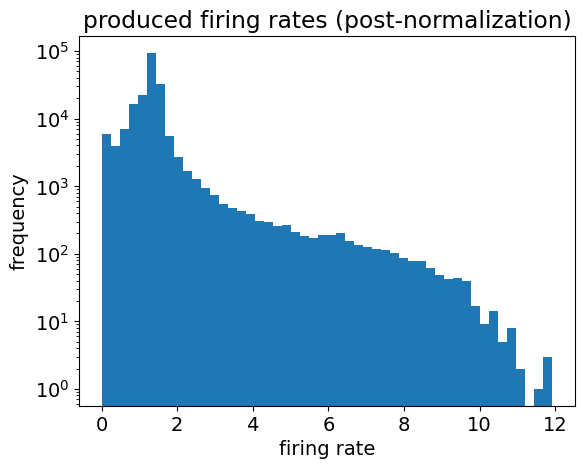

In [12]:
plt.hist(firing_rate.numpy().flatten(), bins=50)
plt.title("produced firing rates (post-normalization)")
plt.ylabel("frequency")
plt.xlabel("firing rate")
plt.yscale("log")
plt.show()

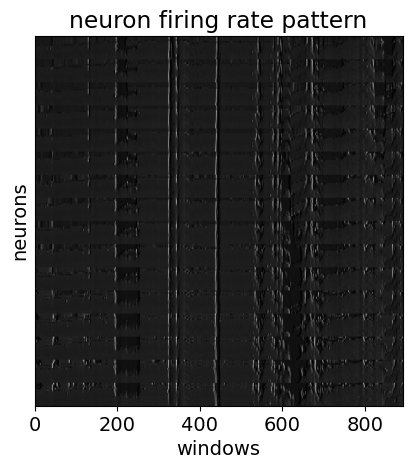

In [13]:
plt.imshow(firing_rate.numpy(), cmap="gray", aspect=4)
plt.title("neuron firing rate pattern")
plt.xlabel("windows")
plt.yticks([], [])
plt.ylabel("neurons")

fig.set
plt.show()

/tmp/ipykernel_795381/2535509703.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return torch.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma**2))


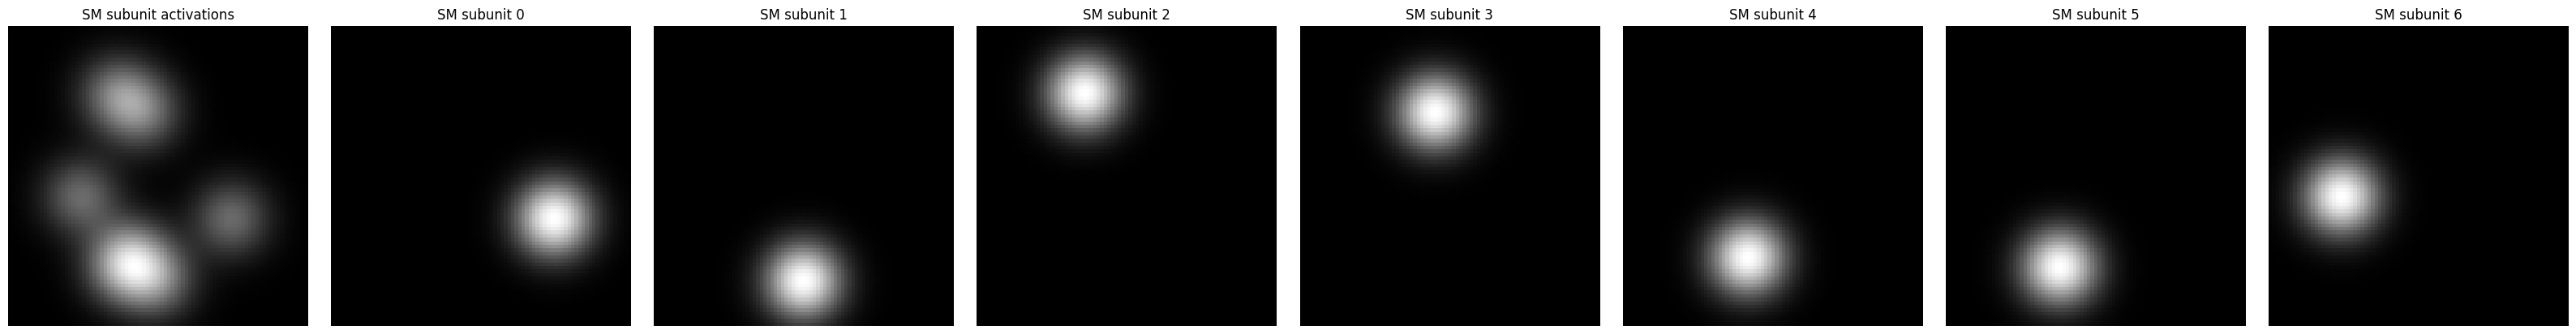

In [242]:

"""from sk_retina_encoders - _spatial_filter()
"""
import torch
import numpy as np
import matplotlib.pyplot as plt

w, h = 85, 85
scale = 5 / 1
n_hotspots = 7
torch.manual_seed(42)
np.random.seed(43)

def SM_gaussian_2d(w, h, sigma):
    # generate coords
    theta_random = np.random.uniform(0, 2*np.pi, 1)
    cy, cx = (h / 2) + (5*scale * np.sin(theta_random)) + np.random.normal(0, 1*scale, 1), (w / 2) + (5*scale * np.cos(theta_random)) + np.random.normal(0, 1*scale, 1)
    y = torch.arange(h, dtype=torch.float32)
    x = torch.arange(w, dtype=torch.float32)
    yy, xx = torch.meshgrid(y, x, indexing='ij')

    # 2D gaussian and return
    return torch.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma**2))

# create the 2 gaussians and normalize
centers = torch.zeros(size=(n_hotspots, w, h))
for i in range(n_hotspots):
    centers[i] = SM_gaussian_2d(w, h, 1.5*scale)

# normalize and combine
centers = centers / torch.sum(centers)

# plot
fig, ax = plt.subplots(1, n_hotspots+1, figsize=((n_hotspots+1)*4, 4))

ax[0].imshow(centers.sum(axis=0), cmap="gray")
ax[0].set_title("SM subunit activations")

for i in range(n_hotspots):
    ax[i+1].imshow(centers[i], cmap="gray")
    ax[i+1].set_title(f"SM subunit {i}")

for a in ax:
    a.axis("off")
fig.set_tight_layout(True)
plt.show()

In [245]:
centers.shape

torch.Size([7, 85, 85])

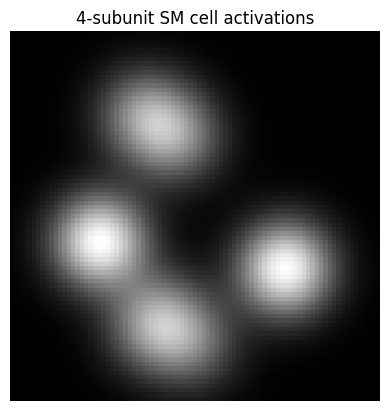

In [258]:
centers_consolidated = torch.stack([
    centers[0] / torch.sum(centers[0]),
    (centers[1] + centers[4] + centers[5]) / torch.sum(centers[1] + centers[4] + centers[5]),
    centers[6] / torch.sum(centers[6]),
    (centers[2] + centers[3]) / torch.sum(centers[2] + centers[3])
])

plt.imshow(centers_consolidated.sum(axis=0), cmap="gray")
plt.title("4-subunit SM cell activations")
plt.axis("off")
plt.show()

In [254]:
centers_consolidated.shape

(85, 85, 4)

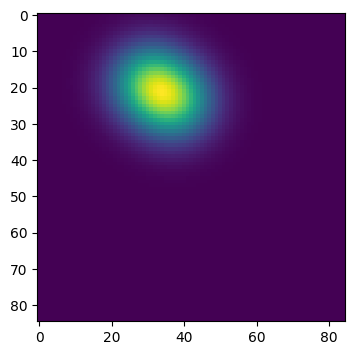

In [ ]:
import cv2

goat = cv2.imread("/home/rotation/Downloads/goat.jpg", 0)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(goat * , cmap="gray")
ax.imshow(centers_consolidated[3])
plt.show()